# Freight Rate Prediction — Spotter ML Engineer Assessment

**Goal:** predict `posted_rate` (the price in $ of a truck load) for the 12,000 loads in `data/validation.csv` (Nov–Dec 2025), using the 48,000 labelled loads in `data/train_test.csv` (Jan–Oct 2025).

- **Type of problem:** regression (we predict a number).
- **Target:** `posted_rate`: present in the training file, absent from the validation file.
- **Approach:** model the **price per mile** (`posted_rate / distance`), then multiply by distance. Distance explains most of the price, so per-mile pricing makes loads of different lengths comparable.
- **Note:** no data dictionary was provided, so the meaning of each column is inferred from the data (section 3).

**Notebook outline**
1. Setup
2. Load the data
3. Understand and fix each feature (distance first, then the target, then the other columns)
4. `quote_signal` analysis (+ label-free regime test)
5. Validation folds
6. Baseline, model comparison and evaluation
7. Final model and predictions
8. Summary

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the data
`train_test.csv` = labelled development data (Jan–Oct). `validation.csv` = loads to predict (Nov–Dec). Dates are parsed as real dates for time-based work.

In [2]:
data = pd.read_csv('data/train_test.csv', parse_dates=['date'])
val  = pd.read_csv('data/validation.csv', parse_dates=['date'])

`data` stays **raw**: the weight test needs the original negative values, and section 7 measures the error on the raw rows. Every fix is applied to a copy, `data_clean`.

In [3]:
data_clean = data.copy()   # all fixes go here; `data` stays raw

## 3. Understand and fix each feature
No data dictionary was provided, so each column is explored on its own: **what it is, its type, its range, and how it relates to the price**. When a problem is found, it is **tested and fixed right there**, on `data_clean`.

**Distance comes first**, before the target: a price can only be judged against a reliable distance.

> Until the corrupted prices are removed (3.3), relationships with price are measured with **medians** and price per mile, which are robust to a few extreme values.

### 3.1 Overview

In [4]:
data.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [5]:
data.shape

(48000, 14)

In [6]:
data.dtypes

load_id                    str
pickup                     str
delivery                   str
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment                  str
weight                 float64
date            datetime64[us]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

In [7]:
data.select_dtypes(exclude=['number', 'datetime']).nunique()   # text columns

load_id      48000
pickup          64
delivery        64
equipment        3
dtype: int64

In [8]:
data.select_dtypes(include='number').nunique()

pickup_lat         64
pickup_lon         63
delivery_lat       64
delivery_lon       63
distance        21204
weight          23678
market_index    32884
quote_signal    37633
posted_rate     45398
dtype: int64

In [9]:
data.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,48000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,2025-05-31 19:53:29.399999,1.083387,2.062468,2373.980682
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,2025-03-18 00:00:00,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,2025-05-31 00:00:00,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,2025-08-15 00:00:00,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,2025-10-31 00:00:00,1.467780,3.610350,25533.000000
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,NaN,0.168091,0.291391,1486.493245


In [10]:
data.isna().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [11]:
int((data.weight < 0).sum())

292

**Observations**
- 48,000 loads, 14 columns.
- `weight` and `market_index` have fewer values than the other columns, so some are missing.
- `weight` has a **negative minimum** (−47,500), which is impossible for a weight.
- `posted_rate` ranges from **$57 to $25,533** while the median is about $2,030, so both ends need checking against distance.
- **Missing values:** `weight` 300, `market_index` 374, no other column. **292 negative weights.** Tested and fixed in 3.7 and 3.9.
- `load_id` has 48,000 distinct values (one per row): it's an identifier, **not a feature**.
- Coordinates have only **64 distinct values**, the number of cities: they describe the city, not the load.

### 3.2 `distance`
Road distance of the trip, in miles. Expected to be the main driver of price. The target (3.3) is judged against distance, so its reliability is checked first.

In [12]:
data.distance.describe()

count    48000.000000
mean      1135.856654
std        728.564416
min         70.000000
25%        550.400000
50%        953.300000
75%       1645.525000
max       3439.800000
Name: distance, dtype: float64

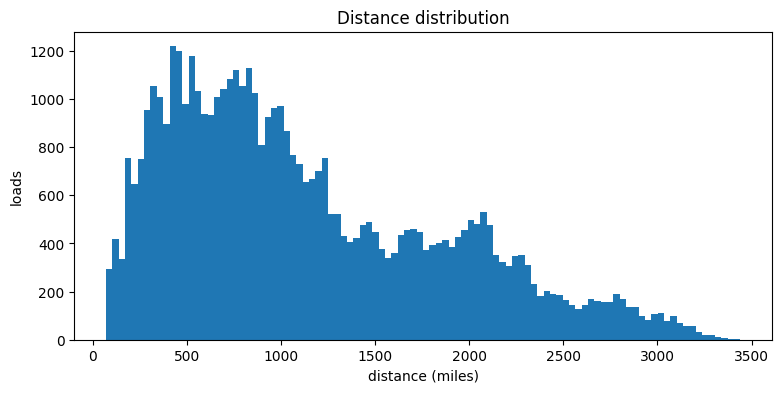

In [13]:
plt.figure(figsize=(9, 4))
plt.hist(data.distance, bins=100)
plt.xlabel('distance (miles)'); plt.ylabel('loads'); plt.title('Distance distribution')
plt.show()

In [14]:
float(data.posted_rate.corr(data.distance))

0.9085191518300771

**Is `distance` reliable?**

**Check 1:** the same route (pickup → delivery) should always have about the same distance. Each load is compared with its route's median distance.

In [15]:
data['lane_median'] = data.groupby(['pickup','delivery']).distance.transform('median')
data['dist_dev'] = data.distance / data.lane_median
print(data.dist_dev.describe(percentiles=[.001, .01, .5, .99, .999]))
print("off by >20%:", ((data.dist_dev > 1.2) | (data.dist_dev < 0.8)).sum())

count    48000.000000
mean         1.000105
std          0.022221
min          0.758684
0.1%         0.887708
1%           0.943325
50%          1.000000
99%          1.057677
99.9%        1.131762
max          1.283372
Name: dist_dev, dtype: float64
off by >20%: 12


- 98% of loads are within **±6%** of their route's median distance, and 99.8% within about ±12%.
- Only **12 rows** deviate by more than 20%, on very short routes where a few miles is a large percentage.

**Distance is consistent and reliable.**

**Check 2:** road distance should be about 1.1–1.4× the straight-line distance computed from the coordinates (haversine formula).

In [16]:
R = 3958.8  # Earth radius in miles
lat1, lon1, lat2, lon2 = [np.radians(data[c]) for c in ['pickup_lat','pickup_lon','delivery_lat','delivery_lon']]
data['straight'] = 2*R*np.arcsin(np.sqrt(np.sin((lat2-lat1)/2)**2 +
                    np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2))
data['road_ratio'] = data.distance / data.straight
print(data.road_ratio.describe(percentiles=[.001, .01, .5, .99, .999]))
print("ratio > 2:", (data.road_ratio > 2).sum())

count    48000.000000
mean         1.194681
std          0.143541
min          1.058090
0.1%         1.112237
1%           1.129599
50%          1.182231
99%          1.403935
99.9%        1.736510
max          9.634919
Name: road_ratio, dtype: float64
ratio > 2: 22


- Typical road/straight-line ratio is **1.18**, which is realistic.
- **22 rows** have a ratio above 2 (up to 9.6), but their distance matches their route (check 1), so the **coordinates** are the unreliable part, not the distance.

**Decision:** `distance` is the main length feature; coordinates are used only as location hints.

**Observations**
- Distance goes from **70 to 3,440 miles** (median 953), with most trips between about 300 and 2,000 miles.
- Correlation with price: **0.91**. Distance is by far the strongest driver of price.
- **Reliable:** the same lane always has about the same distance (99.8% within ±12%). The 22 rows with an impossible road/straight-line ratio sit on 4 lanes (Austin ↔ Lubbock, New Orleans ↔ Shreveport) whose city coordinates are imprecise; their distance is normal.
- **Fix:** none needed. `distance` is trusted and used as the length feature.

### 3.3 Target: `posted_rate`
The price in \$ paid for one load. This is what we predict. Now that distance is verified, the price can be checked against it.

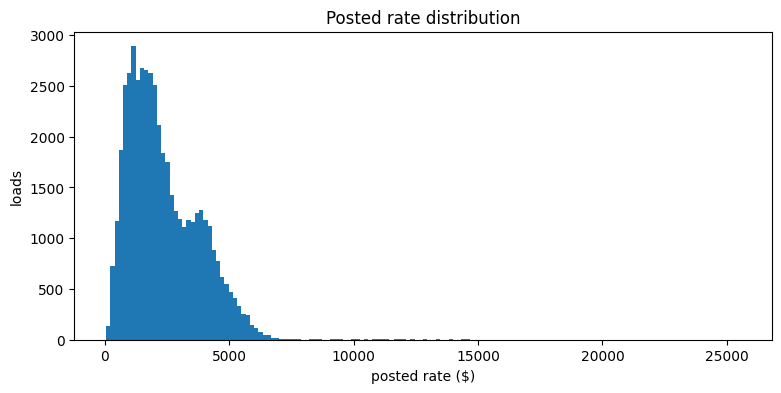

In [17]:
plt.figure(figsize=(9,4))
plt.hist(data.posted_rate, bins=150)
plt.xlabel('posted rate ($)'); plt.ylabel('loads')
plt.title('Posted rate distribution')
plt.show()

#### Basic checks

In [18]:
print("missing:", data.posted_rate.isna().sum())
print("zero or negative:", (data.posted_rate <= 0).sum())

missing: 0
zero or negative: 0


No missing and no zero or negative prices.

#### Price per mile
With distance verified, `rpm = posted_rate / distance` is a fair way to spot wrong prices.

In [19]:
data['rpm'] = data.posted_rate / data.distance
print(data.rpm.describe(percentiles=[.005, .01, .05, .5, .95, .99, .995]))

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
0.5%         0.746195
1%           1.673521
5%           1.807533
50%          2.145348
95%          2.735925
99%          3.176940
99.5%        6.314326
max         14.125294
Name: rpm, dtype: float64


90% of loads cost between **\$1.81 and \$2.74 per mile**, but the extremes go from \$0.33 to \$14.13 per mile.

In [20]:
print(data.sort_values('rpm').head(10)[['distance','equipment','posted_rate','rpm']])
print(data.sort_values('rpm').tail(10)[['distance','equipment','posted_rate','rpm']])

       distance equipment  posted_rate       rpm
14102    2536.4   Dry Van       846.42  0.333709
25798    2894.3   Dry Van       969.83  0.335083
23043    2983.4   Dry Van      1047.91  0.351247
46173    2490.9   Dry Van       880.13  0.353338
508      1976.4   Flatbed       699.41  0.353881
2511     1644.3   Flatbed       596.04  0.362489
40600    2210.6   Dry Van       808.74  0.365846
22458    1632.3   Dry Van       599.77  0.367439
22464    1909.1   Dry Van       709.46  0.371620
1555     2415.0   Dry Van       911.44  0.377408
       distance equipment  posted_rate        rpm
21968     254.5   Dry Van      3220.66  12.654853
1415      198.2    Reefer      2509.96  12.663774
45483     153.8   Dry Van      1971.21  12.816710
28012     604.3    Reefer      7773.37  12.863429
23369     412.4   Flatbed      5308.96  12.873327
27969     589.9    Reefer      7597.52  12.879335
17070     201.5   Flatbed      2609.34  12.949578
870       305.6    Reefer      4069.24  13.315576
36609      

- **Cheapest rows:** about \$0.33–0.38/mile on long trips (1,600–3,000 miles), e.g. 2,536 miles for \$846. Not a realistic market price.
- **Most expensive rows:** about \$12.6–14.1/mile on short and medium trips, roughly 6× a normal rate.

#### Corrupted rates: thresholds
Thresholds are placed at the natural gaps visible in the histogram below.

In [21]:
low, high = 1.35, 4.0
bad = (data.rpm < low) | (data.rpm > high)
print(bad.sum(), "suspicious rows =", round(bad.mean()*100, 2), "%")

677 suspicious rows = 1.41 %


In [22]:
normal = data.rpm[~bad].median()
print("normal median $/mile:", round(normal, 2))
print("low group  ÷:", round(normal / data.rpm[data.rpm < low].median(), 1))
print("high group ×:", round(data.rpm[data.rpm > high].median() / normal, 1))

normal median $/mile: 2.15
low group  ÷: 3.5
high group ×: 3.5


- **677 rows (1.41%)** are outside \$1.35–\$4.00 per mile.
- By median, they are about **3.5× too low or too high**, with extremes up to about 6×. There is **no single correction factor**, so they cannot be repaired reliably.

**Decision:** exclude them from training. Test error will be reported both with and without these rows.

#### Charts

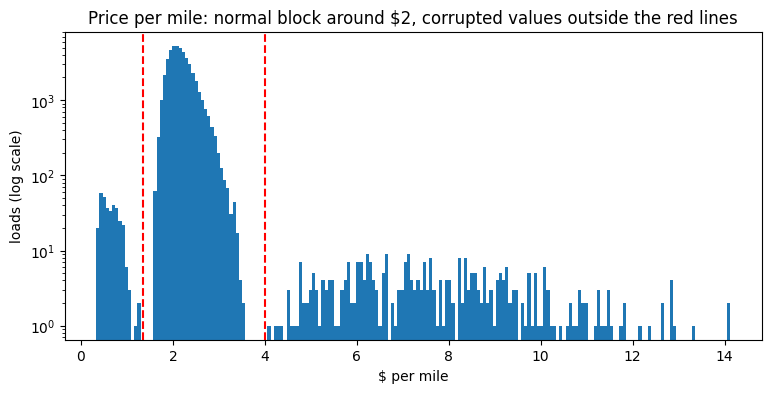

In [23]:
plt.figure(figsize=(9,4))
plt.hist(data.rpm, bins=200)
plt.yscale('log')
plt.axvline(low, color='red', ls='--'); plt.axvline(high, color='red', ls='--')
plt.xlabel('$ per mile'); plt.ylabel('loads (log scale)')
plt.title('Price per mile: normal block around $2, corrupted values outside the red lines')
plt.show()

Valid rates sit between about \$1.4 and \$3.6/mile. Corrupted values form a separate low cluster (\$0.3–1.3) and a scattered high tail (\$4–14). The thresholds 1.35 and 4.0 fall in the empty gaps.

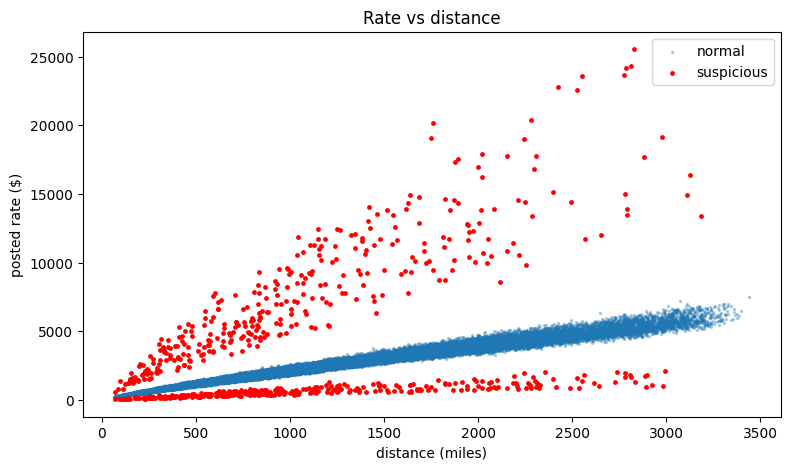

In [24]:
plt.figure(figsize=(9,5))
plt.scatter(data.distance[~bad], data.posted_rate[~bad], s=2, alpha=0.3, label='normal')
plt.scatter(data.distance[bad],  data.posted_rate[bad],  s=6, color='red', label='suspicious')
plt.xlabel('distance (miles)'); plt.ylabel('posted rate ($)'); plt.legend()
plt.title('Rate vs distance')
plt.show()

Valid loads form a single band that rises with distance; the excluded rows (red) lie far above or below it.

#### Fix
Drop the 677 corrupted rates from `data_clean` (training only). The raw `data` keeps them, to report the error with them in section 7.

In [25]:
data_clean = data_clean[~bad].copy()
data_clean['rpm'] = data_clean.posted_rate / data_clean.distance
print(len(data), "->", len(data_clean), "rows")

48000 -> 47323 rows


**Observations**
- Prices go from **\$57 to \$25,533** (median \$2,031). The distribution is right-skewed with two humps (short vs long trips), so the model predicts **price per mile**, then multiplies by distance.
- No missing, zero or negative prices.
- Per mile, 90% of loads cost between \$1.81 and \$2.74, but **677 rows (1.41%)** are about **3.5× too low or too high**, with no single correction factor.
- **Fix:** removed from training (47,323 rows left). Kept in `data` to measure the error with them.

### 3.4 Cities and lanes: `pickup`, `delivery`
A **lane** is a route pickup → delivery. Questions: how many cities and lanes, and are the validation cities and lanes also present in the training data? If a city only appears in validation, the model has never seen it.

In [26]:
data.groupby(['pickup', 'delivery']).size().sort_values(ascending=False).head(10)

pickup      delivery     
Columbia    Oklahoma City    39
Phoenix     Shreveport       39
Lexington   Atlanta          39
Fort Wayne  Philadelphia     38
Shreveport  Hartford         37
Fort Wayne  Hartford         37
Richmond    Oklahoma City    37
            Phoenix          37
Lexington   Kansas City      37
            Cincinnati       37
dtype: int64

In [27]:
all_train = set(data.pickup) | set(data.delivery)
print(data.pickup.nunique(), "cities |", data.groupby(['pickup', 'delivery']).ngroups, "lanes")
new_cities = (set(val.pickup) | set(val.delivery)) - all_train
print("cities in validation never seen in training:", sorted(new_cities))
touch = val.pickup.isin(new_cities) | val.delivery.isin(new_cities)
print(touch.sum(), "validation loads involve a new city =", round(touch.mean() * 100, 1), "%")

64 cities | 4014 lanes
cities in validation never seen in training: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
1447 validation loads involve a new city = 12.1 %


**Observations**
- **64 cities**, each used both as pickup and delivery, and **4,014 lanes** with about 12 loads each (1 to 39).
- **8 cities in validation never appear in training** (Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego). **1,447 validation loads (12.1%)** involve one of them.
- **Consequence:** city names can't be features, because the model would know nothing about a new city. The model uses **coordinates and distance** instead, which exist for every load, including new cities.

### 3.5 Coordinates: `pickup_lat`, `pickup_lon`, `delivery_lat`, `delivery_lon`
GPS position of the pickup and delivery cities. Question: does each city always have the same coordinates, or do they change from load to load?

In [28]:
data.groupby('pickup')[['pickup_lat', 'pickup_lon']].nunique().max()

pickup_lat    1
pickup_lon    1
dtype: int64

In [29]:
data.groupby('delivery')[['delivery_lat', 'delivery_lon']].nunique().max()

delivery_lat    1
delivery_lon    1
dtype: int64

**Observations**
- Each city always has **exactly the same coordinates**, so coordinates describe the city, not the load (64 positions).
- They're the only way to place the 8 new validation cities on the map, so they're kept as features.
- Some positions are approximate (the 4 lanes with an impossible road/straight-line ratio in 3.2), so they're used as **location hints**; `distance` remains the length feature.

### 3.6 `equipment`
Type of truck: **Dry Van** (standard closed trailer), **Flatbed** (open platform), **Reefer** (refrigerated).

In [30]:
data.equipment.value_counts(normalize=True)

equipment
Dry Van    0.566708
Reefer     0.250937
Flatbed    0.182354
Name: proportion, dtype: float64

In [31]:
rpm_tmp = data.posted_rate / data.distance

data.groupby('equipment').agg(
    loads=('posted_rate', 'size'),
    median_distance=('distance', 'median'),
    median_rate=('posted_rate', 'median'),
    median_rpm=('posted_rate', lambda s: rpm_tmp[s.index].median()),
)

,loads,median_distance,median_rate,median_rpm
equipment,,,,
Dry Van,27202,957.55,1953.035,2.046203
Flatbed,8753,940.00,2076.810,2.219683
Reefer,12045,950.20,2196.670,2.311540


**Observations**
- **Dry Van** is the most common (57% of loads), then Reefer (25%) and Flatbed (18%).
- Price per mile rises from **Dry Van \$2.05** to **Flatbed \$2.22** to **Reefer \$2.31** (+13%), while median distances are almost identical (940–958 miles).
- So equipment has **its own effect** on price, not a distance effect: an important feature.

### 3.7 `weight`
Weight of the cargo, in pounds (lb). First the normal values and the link with price, then the missing and negative values: test, then fix.

In [32]:
w_ok = data.weight > 0                     # positive weights only
print("Pearson :", round(data.weight[w_ok].corr(rpm_tmp[w_ok]), 3))
print("Spearman:", round(data.weight[w_ok].corr(rpm_tmp[w_ok], method='spearman'), 3))

Pearson : 0.093
Spearman: 0.199


                    loads  median_rpm
weight                               
(4957.5, 13500.0]     644       2.056
(13500.0, 22000.0]   5127       2.065
(22000.0, 30500.0]  15668       2.107
(30500.0, 39000.0]  17470       2.175
(39000.0, 47500.0]   8499       2.213


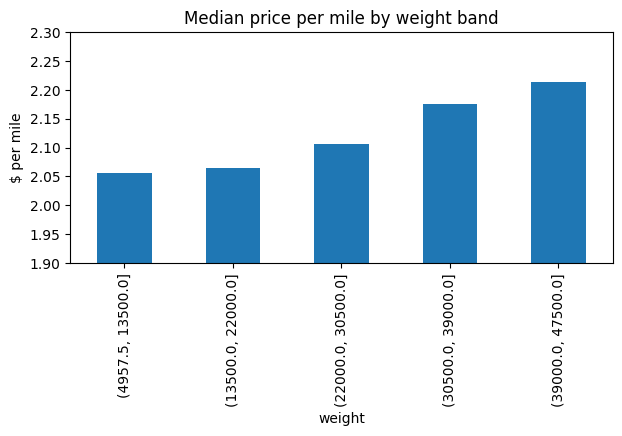

In [33]:
bands = pd.cut(data.weight[w_ok], 5)       # 5 equal-width weight bands
table = rpm_tmp[w_ok].groupby(bands, observed=True).agg(loads='size', median_rpm='median').round(3)
print(table)

table.median_rpm.plot(kind='bar', figsize=(7, 3), title='Median price per mile by weight band')
plt.ylabel('$ per mile'); plt.ylim(1.9, 2.3); plt.show()

**Observations**
- Weight has a **small but consistent** effect: price per mile rises from about \$2.06 for the lightest loads to \$2.21 for the heaviest (+7%).
- Correlation is weak (Pearson 0.09, Spearman 0.20): Spearman is higher because it ignores the extreme corrupted prices. Weight is a **secondary feature**, much weaker than distance and equipment.

**Problem:** 300 missing and 292 negative weights. Is a negative weight only a sign error (−31,000 instead of 31,000), or a completely wrong value?
If it's a sign error, the negative weights made positive must have the **same distribution** as the normal positive weights.

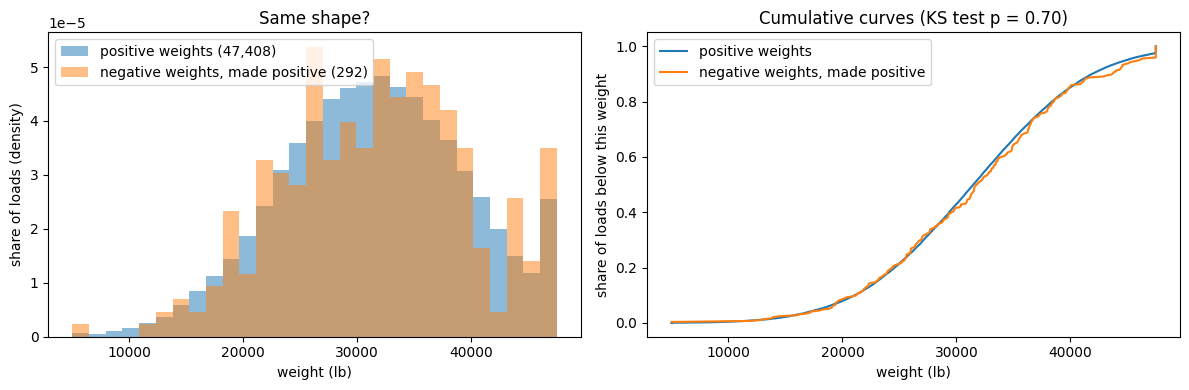

In [34]:
from scipy.stats import ks_2samp

neg = data.weight[data.weight < 0].abs()      # negative weights, made positive
pos = data.weight[data.weight > 0]            # normal weights
ks = ks_2samp(neg, pos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(5000, 47500, 30)

# Chart 1: histograms on the same scale
ax1.hist(pos, bins=bins, density=True, alpha=0.5, label=f'positive weights ({len(pos):,})')
ax1.hist(neg, bins=bins, density=True, alpha=0.5, label=f'negative weights, made positive ({len(neg)})')
ax1.set_xlabel('weight (lb)'); ax1.set_ylabel('share of loads (density)')
ax1.set_title('Same shape?'); ax1.legend()

# Chart 2: cumulative curves (what the KS test compares)
ax2.plot(np.sort(pos), np.arange(1, len(pos) + 1) / len(pos), label='positive weights')
ax2.plot(np.sort(neg), np.arange(1, len(neg) + 1) / len(neg), label='negative weights, made positive')
ax2.set_xlabel('weight (lb)'); ax2.set_ylabel('share of loads below this weight')
ax2.set_title(f'Cumulative curves (KS test p = {ks.pvalue:.2f})'); ax2.legend()

plt.tight_layout(); plt.show()

The negative weights, made positive, follow **the same distribution** as the normal weights: same range, same peak around 30,000 lb, and cumulative curves that almost overlap. Kolmogorov–Smirnov test: largest gap 0.04, **p ≈ 0.70**, so no detectable difference.

**Conclusion:** they are sign errors, not wrong values, and `abs()` is the right fix.

In [35]:
data_clean['weight'] = data_clean.weight.abs()
WEIGHT_MEDIAN = data_clean.weight.median()      
data_clean['weight'] = data_clean.weight.fillna(WEIGHT_MEDIAN)
print(data_clean.weight.isna().sum(), "missing |", (data_clean.weight < 0).sum(), "negative | median:", WEIGHT_MEDIAN)

0 missing | 0 negative | median: 31508.0


**Fix:** negative → absolute value (sign errors); missing → training median `WEIGHT_MEDIAN`. The same value is reused for validation and December, so all three tables are treated the same way.

### 3.8 `date`
Day of the load. Training covers Jan–Oct 2025 and validation Nov–Dec 2025, so time matters for how we validate.

In [36]:
rpm_tmp.groupby(data.date.dt.dayofweek).median()

date
0    2.126141
1    2.139350
2    2.163024
3    2.170587
4    2.157178
5    2.131724
6    2.127364
dtype: float64

In [37]:
rpm_tmp.groupby(data.date.dt.month).median()

date
1     2.029158
2     2.061143
3     2.139279
4     2.146699
5     2.190194
6     2.247885
7     2.187422
8     2.120525
9     2.159622
10    2.163828
dtype: float64

**Observations**
- Training covers **every day from 1 Jan to 31 Oct 2025** (about 4,800 loads per month). Validation is **Nov (5,836) and Dec (6,164)**: the future, so validation must be time-based.
- **Day of week:** price per mile is highest on Thursday (\$2.17) and lowest on Monday and Sunday (\$2.13). A small (about ±1%) but regular pattern, kept as the `dow` feature.
- **Month:** the market level moves from \$2.03 (Jan) up to \$2.25 (Jun), then \$2.12–2.16 (Aug–Oct). The month itself can't be a feature: the model has never seen a November or December.

### 3.9 `market_index`
Unknown meaning (no data dictionary): it looks like a market-level indicator. Question: how does it move over time, and does it follow the price?

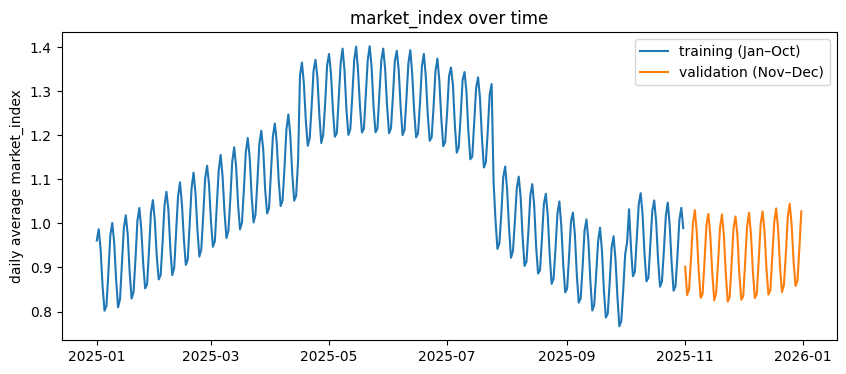

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(data.groupby('date').market_index.mean(), label='training (Jan–Oct)')
plt.plot(val.groupby('date').market_index.mean(), label='validation (Nov–Dec)')
plt.ylabel('daily average market_index'); plt.legend(); plt.title('market_index over time')
plt.show()

      median_rpm  mean_market_index  corr_within_month
date                                                  
1          2.029              0.927              0.036
2          2.061              0.996              0.035
3          2.139              1.073              0.058
4          2.147              1.208              0.074
5          2.190              1.301              0.038
6          2.248              1.280              0.027
7          2.187              1.201              0.069
8          2.121              0.981              0.032
9          2.160              0.893              0.019
10         2.164              0.958              0.056

Correlation between the monthly levels: 0.67


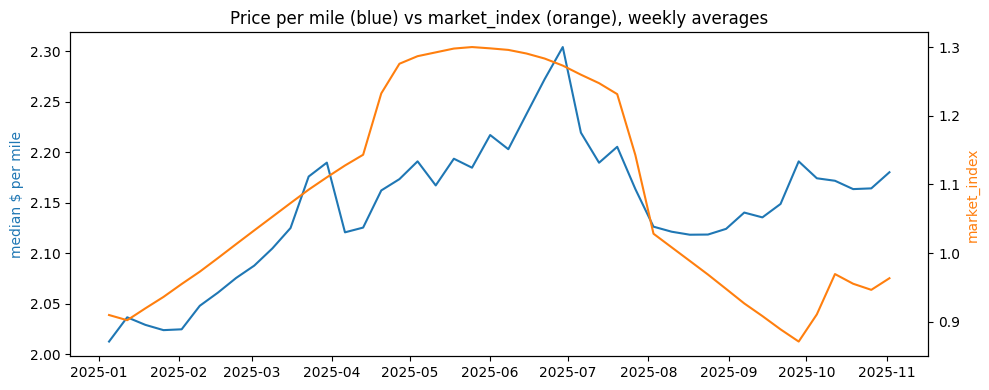

In [39]:
month = data.date.dt.month

# Table: monthly price level vs monthly market_index level
monthly = pd.DataFrame({
    'median_rpm': rpm_tmp.groupby(month).median(),
    'mean_market_index': data.market_index.groupby(month).mean(),
    'corr_within_month': [rpm_tmp[month == m].corr(data.market_index[month == m])
                          for m in sorted(month.unique())],
}).round(3)
print(monthly)
print("\nCorrelation between the monthly levels:", round(monthly.median_rpm.corr(monthly.mean_market_index), 2))

# Chart: weekly averages, two y-axes because the scales are different
weekly_rpm = rpm_tmp.groupby(data.date).median().resample('W').mean()
weekly_mi = data.market_index.groupby(data.date).mean().resample('W').mean()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(weekly_rpm.index, weekly_rpm.values, color='tab:blue')
ax1.set_ylabel('median $ per mile', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(weekly_mi.index, weekly_mi.values, color='tab:orange')
ax2.set_ylabel('market_index', color='tab:orange')
ax1.set_title('Price per mile (blue) vs market_index (orange), weekly averages')
fig.tight_layout(); plt.show()

**Observations**
- **Per load, `market_index` says almost nothing** about the price: correlation within each month is only 0.02–0.07.
- **Over time, it partly follows the market level** (0.67 between monthly levels), but **the link breaks after July**: the index drops to 0.89 in September, its lowest value, while the price per mile rises again. This is **drift**.
- Risk: a model would learn "low index = cheap", which is wrong for Sep–Oct, and Nov–Dec values (about 0.92–0.94) sit in that broken period. Tested with and without it in section 6.

**Problem:** 374 missing values.
**Fix:** fill with the average `market_index` of the **same day**: the index moves over time, so the same day is the closest estimate.

In [40]:
data_clean['market_index'] = data_clean.market_index.fillna(
    data_clean.groupby('date').market_index.transform('mean'))
print(data_clean.market_index.isna().sum(), "missing")

0 missing


### 3.10 `quote_signal`
Unknown meaning. First look only here; the full analysis is in section 4.

In [41]:
data.quote_signal.describe() 

count    48000.000000
mean         2.062468
std          0.291391
min          0.692280
25%          1.891030
50%          2.055750
75%          2.221685
max          3.610350
Name: quote_signal, dtype: float64

In [42]:
float(rpm_tmp.corr(data.quote_signal))

0.04934221408928225

**Observations**
- Values from 0.69 to 3.61, centred around 2.06: the same scale as a price per mile.
- Overall correlation with price per mile is **almost zero (0.05)**. Section 4 shows why: inside each month it is about **±0.99**, with the sign flipping between months, so the opposite signs cancel out over the year.

### 3.11 Feature summary

| Column | Type | What it is | Range / values | Link with price | Issue → fix |
|---|---|---|---|---|---|
| `load_id` | text | row identifier | 48,000 unique | none | not a feature |
| `pickup`, `delivery` | text | cities | 64 cities, 4,014 lanes | through location | 8 cities only in validation → use coordinates, not names |
| coordinates | number | city position | 64 positions | location effect | approximate for a few cities → location hints only |
| `distance` | number | road miles | 70 – 3,440 | **very strong** (corr 0.91) | reliable → none |
| `equipment` | category | truck type | Dry Van 57%, Reefer 25%, Flatbed 18% | **strong** (+13% Reefer vs Dry Van) | none |
| `weight` | number | cargo lb | 5,000 – 47,500 | weak (+7% heaviest vs lightest) | 292 sign errors → `abs()`; 300 missing → training median |
| `date` | date | load day | 1 Jan – 31 Oct (val: Nov–Dec) | weekly pattern ±1%, level moves by month | → day of week feature; time-based validation |
| `market_index` | number | unknown (market level?) | 0.68 – 1.47 | weak, **drifts** after July | 374 missing → same-day mean; tested in section 6 |
| `quote_signal` | number | unknown | 0.69 – 3.61 | ±0.99 per month, **sign flips** | analysed in section 4 |
| `posted_rate` (target) | number | price in \$ | \$57 – \$25,533 | – | 677 corrupted (3.5× off) → removed from training |

## 4. `quote_signal` analysis
`quote_signal` is the strongest candidate feature. Check how it relates to price per mile, month by month.

In [43]:
data_clean['month'] = data_clean.date.dt.month
for m, g in data_clean.groupby('month'):
    print(m, round(g.rpm.corr(g.quote_signal), 3))

1 0.996
2 0.996
3 0.997
4 -0.993
5 -0.994
6 0.997
7 -0.994
8 -0.02
9 0.997
10 -0.994


**`quote_signal` is almost a copy of price per mile (|corr| ≈ 0.99), but its direction changes by month:**

| Months | Correlation with price per mile | Behaviour |
|---|---|---|
| Jan, Feb, Mar, Jun, Sep | ≈ +0.996 | `quote_signal` ≈ price per mile |
| Apr, May, Jul, Oct | ≈ −0.994 | `quote_signal` is the price **inverted** |
| Aug | ≈ −0.02 | **no relationship**: pure noise |

The key question is therefore: **which behaviour will Nov–Dec (the months to predict) follow?** Their prices are unknown, but their `quote_signal` values are visible.

In [44]:
day_tr = data_clean.groupby('date').quote_signal.mean()
day_val = val.groupby('date').quote_signal.mean()
print("TRAIN (daily average quote_signal, by month):")
print(day_tr.groupby(day_tr.index.month).agg(['min','mean','max']).round(3))
print("\nVALIDATION Nov–Dec:")
print(day_val.groupby(day_val.index.month).agg(['min','mean','max']).round(3))

TRAIN (daily average quote_signal, by month):
        min   mean    max
date                     
1     2.010  2.067  2.137
2     2.045  2.096  2.158
3     2.102  2.179  2.252
4     1.884  1.964  2.026
5     1.878  1.914  1.981
6     2.203  2.296  2.420
7     1.838  1.922  2.000
8     2.009  2.052  2.076
9     2.140  2.201  2.273
10    1.903  1.943  1.987

VALIDATION Nov–Dec:
        min   mean    max
date                     
11    2.025  2.055  2.088
12    2.009  2.048  2.089


- "Normal" months mostly sit **high** (daily average above ~2.1), "inverted" months sit **low** (below ~2.0).
- **Nov (2.03–2.09) and Dec (2.01–2.09) look most like August (2.01–2.08)**, not like the inverted months.
- January (2.01–2.14) also overlaps, so the level alone is not conclusive; see the label-free test below.

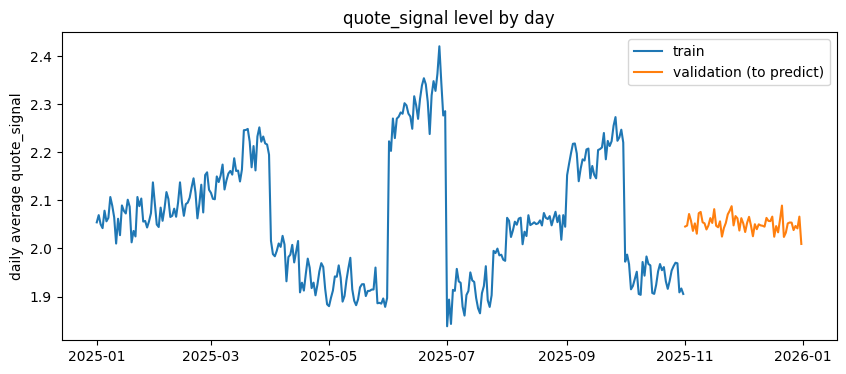

In [45]:
plt.figure(figsize=(10,4))
plt.plot(day_tr.index, day_tr.values, label='train')
plt.plot(day_val.index, day_val.values, label='validation (to predict)')
plt.ylabel('daily average quote_signal'); plt.legend()
plt.title('quote_signal level by day'); plt.show()

### 4.1 Label-free regime test
If `quote_signal` follows price, it must also follow what drives price: Reefer loads cost more per mile than Dry Van, and price per mile falls as distance grows. In inverted months both effects flip; if `quote_signal` is noise, both disappear. This test needs **no prices**, so it can be run on the Nov–Dec loads.

In [46]:
def regime_test(df):
    g = df.groupby(df.date.dt.month)
    return pd.DataFrame({
        'qs_spread': g.quote_signal.std(),
        'reefer_minus_dryvan': g.apply(lambda x: x[x.equipment=='Reefer'].quote_signal.mean()
                                               - x[x.equipment=='Dry Van'].quote_signal.mean()),
        'corr_with_distance': g.apply(lambda x: x.quote_signal.corr(x.distance)),
    }).round(3)

print("TRAIN"); print(regime_test(data_clean))
print("\nVALIDATION"); print(regime_test(val))

TRAIN
      qs_spread  reefer_minus_dryvan  corr_with_distance
date                                                    
1         0.250                0.245              -0.722
2         0.250                0.253              -0.715
3         0.273                0.282              -0.698
4         0.259               -0.268               0.713
5         0.265               -0.265               0.724
6         0.289                0.317              -0.700
7         0.265               -0.267               0.716
8         0.223               -0.002               0.013
9         0.280                0.299              -0.701
10        0.269               -0.239               0.715

VALIDATION
      qs_spread  reefer_minus_dryvan  corr_with_distance
date                                                    
11        0.220                0.001               0.017
12        0.219               -0.002               0.005


**Result**

| Months | Reefer − Dry Van | Corr. with distance | Spread |
|---|---|---|---|
| Normal (Jan–Mar, Jun, Sep) | +0.25 to +0.32 | ≈ −0.70 | 0.25–0.29 |
| Inverted (Apr, May, Jul, Oct) | −0.24 to −0.27 | ≈ +0.71 | 0.26–0.27 |
| **August** | **0.00** | **0.01** | **0.22** |
| **Nov, Dec (to predict)** | **0.00** | **0.01** | **0.22** |

**Key finding:** in Nov–Dec, `quote_signal` behaves exactly like August: it shows no link to equipment or distance and has the same lower spread. It carries **no information about price** in the months we must predict. A model that relies on it (the best feature in 9 of 10 training months) would fail on Nov–Dec.

**Consequences**
1. The final model **does not use `quote_signal`**. Features: distance, equipment, weight, coordinates, date features; `market_index` tested with and without.
2. Validation must mimic Nov–Dec. August is the only training month that behaves like the future:
   - Fold A: train Jan–Jul → test **Aug** (most realistic)
   - Fold B: train Jan–Aug → test Sep–Oct
3. The report compares a model **with** and **without** `quote_signal` to show why it is excluded.

## 5. Validation folds
Time-based splits only (never random), because the goal is to predict **future** months:
- **Fold A:** train Jan–Jul → test **August**, the only training month whose `quote_signal` behaves like Nov–Dec (most realistic check).
- **Fold B:** train Jan–Aug → test Sep–Oct (the most recent data).

Metrics: MAE in \$ and MAPE in %.

In [47]:
fold_A_train = data_clean[data_clean.date <  '2025-08-01']                                     # Jan–Jul
fold_A_test  = data_clean[(data_clean.date >= '2025-08-01') & (data_clean.date < '2025-09-01')] # Aug (behaves like Nov–Dec)
fold_B_train = data_clean[data_clean.date <  '2025-09-01']                                     # Jan–Aug
fold_B_test  = data_clean[data_clean.date >= '2025-09-01']                                     # Sep–Oct
for name, df in [('A train', fold_A_train), ('A test', fold_A_test), ('B train', fold_B_train), ('B test', fold_B_test)]:
    print(name, len(df), df.date.min().date(), '->', df.date.max().date())

A train 33253 2025-01-01 -> 2025-07-31
A test 4691 2025-08-01 -> 2025-08-31
B train 37944 2025-01-01 -> 2025-08-31
B test 9379 2025-09-01 -> 2025-10-31


In [48]:
data_clean['equip'] = data_clean.equipment.map({'Dry Van': 0, 'Flatbed': 1, 'Reefer': 2})
data_clean['dow'] = data_clean.date.dt.dayofweek          # day of week

def evaluate(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs(y_true - y_pred) / y_true) * 100
    return f"MAE ${mae:7.1f} | MAPE {mape:5.2f}%"

folds = {
    'A (test Aug)':     (data_clean.date < '2025-08-01',
                         (data_clean.date >= '2025-08-01') & (data_clean.date < '2025-09-01')),
    'B (test Sep–Oct)': (data_clean.date < '2025-09-01', data_clean.date >= '2025-09-01'),
}

## 6. Baseline and model comparison
**Baseline:** median price per mile of each equipment type (from the training part) × distance.

In [49]:
for name, (tr, te) in folds.items():
    med = data_clean[tr].groupby('equip').rpm.median()
    pred = data_clean[te]['equip'].map(med) * data_clean[te].distance
    print(name, "baseline:", evaluate(data_clean[te].posted_rate, pred))

A (test Aug) baseline: MAE $  193.4 | MAPE  8.20%
B (test Sep–Oct) baseline: MAE $  175.1 | MAPE  8.09%


**Models:** gradient boosting (`HistGradientBoostingRegressor`) predicting **price per mile**, then × distance. Three feature sets are compared:
- base features (distance, equipment, weight, coordinates, day of week), **no** `quote_signal`
- base + `market_index`
- base + `quote_signal`

In [50]:
from sklearn.ensemble import HistGradientBoostingRegressor

base = ['distance', 'equip', 'weight', 'pickup_lat', 'pickup_lon',
        'delivery_lat', 'delivery_lon', 'dow']
versions = {
    'without quote_signal': base,
    'no qs, WITH market_index': base + ['market_index'],
    'WITH quote_signal': base + ['quote_signal'],
}

for name, (tr, te) in folds.items():
    for vname, feats in versions.items():
        model = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
                    categorical_features=[feats.index('equip')], random_state=0)
        model.fit(data_clean.loc[tr, feats], data_clean.loc[tr, 'rpm'])
        pred = model.predict(data_clean.loc[te, feats]) * data_clean.loc[te, 'distance']
        print(f"{name:18s} {vname:28s}", evaluate(data_clean.loc[te, 'posted_rate'], pred))

A (test Aug)       without quote_signal         MAE $   40.9 | MAPE  1.74%
A (test Aug)       no qs, WITH market_index     MAE $   66.6 | MAPE  2.85%
A (test Aug)       WITH quote_signal            MAE $  110.4 | MAPE  5.33%
B (test Sep–Oct)   without quote_signal         MAE $   42.0 | MAPE  1.80%
B (test Sep–Oct)   no qs, WITH market_index     MAE $  116.0 | MAPE  4.83%
B (test Sep–Oct)   WITH quote_signal            MAE $   32.4 | MAPE  1.33%


**Results**

| Model | Fold A: test Aug (like Nov–Dec) | Fold B: test Sep–Oct |
|---|---|---|
| Baseline (median \$/mile per equipment) | \$193.4 · 8.20% | \$175.1 · 8.09% |
| **No `quote_signal` (final)** | **\$40.9 · 1.74%** | **\$42.0 · 1.80%** |
| No `quote_signal`, WITH `market_index` | \$66.6 · 2.85% | \$116.0 · 4.83% |
| WITH `quote_signal` | \$110.4 · 5.33% | \$32.4 · 1.33% |

- The model **with `quote_signal`** wins on Sep–Oct (\$32) but is the **worst on August** (\$110), the only month that behaves like Nov–Dec. It would fail on the months we must predict.
- **`market_index` makes both folds worse.** It follows prices until July, then drifts (it falls in September while prices don't).
- The final model cuts the baseline error by about **4–5×**.

**Decision — final features:** distance, equipment, weight, coordinates, day of week.

**Target choice: price per mile vs the price directly.** The model learns the price per mile, then multiplies by distance. To check that choice, the same final features are trained on both targets.

In [51]:
for name, (tr, te) in folds.items():
    for target in ['rpm', 'posted_rate']:
        m_t = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
                  categorical_features=[base.index('equip')], random_state=0)
        m_t.fit(data_clean.loc[tr, base], data_clean.loc[tr, target])
        pred = m_t.predict(data_clean.loc[te, base])
        if target == 'rpm':
            pred = pred * data_clean.loc[te, 'distance']      # back to dollars
        print(f"{name:18s} target = {target:12s}", evaluate(data_clean.loc[te, 'posted_rate'], pred))

A (test Aug)       target = rpm          MAE $   40.9 | MAPE  1.74%
A (test Aug)       target = posted_rate  MAE $   42.9 | MAPE  1.93%
B (test Sep–Oct)   target = rpm          MAE $   42.0 | MAPE  1.80%
B (test Sep–Oct)   target = posted_rate  MAE $   44.1 | MAPE  1.96%


Predicting the **price per mile** is about **\$2 better on both folds** (\$40.9 vs \$42.9 on August, \$42.0 vs \$44.1 on Sep–Oct). It also keeps long trips correct, because tree models can't extrapolate beyond the prices they have seen, while price per mile × distance grows with distance by construction.

### 6.1 Evaluation of the chosen model
A closer look at the final feature set on Fold B (Sep–Oct, the most recent and largest test period): more metrics, charts, where the errors are, and how it handles cities it has never seen.

In [52]:
from sklearn.metrics import r2_score

tr, te = folds['B (test Sep–Oct)']
m = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
        categorical_features=[base.index('equip')], random_state=0)
m.fit(data_clean.loc[tr, base], data_clean.loc[tr, 'rpm'])

res = data_clean.loc[te, ['equipment', 'distance', 'posted_rate']].copy()
res['pred'] = m.predict(data_clean.loc[te, base]) * res.distance
res['err'] = res.pred - res.posted_rate                 # > 0 = too high, < 0 = too low
res['ape'] = res.err.abs() / res.posted_rate * 100      # error in % of the price

print(f"MAE  ${res.err.abs().mean():.1f} | median error ${res.err.abs().median():.1f} | RMSE ${np.sqrt((res.err**2).mean()):.1f}")
print(f"MAPE {res.ape.mean():.2f}% | R² {r2_score(res.posted_rate, res.pred):.4f} | bias ${res.err.mean():.1f}")
print(f"{(res.ape < 5).mean():.1%} of loads predicted within 5% of the real price")

MAE  $42.0 | median error $27.6 | RMSE $62.2
MAPE 1.80% | R² 0.9980 | bias $-15.4
96.8% of loads predicted within 5% of the real price


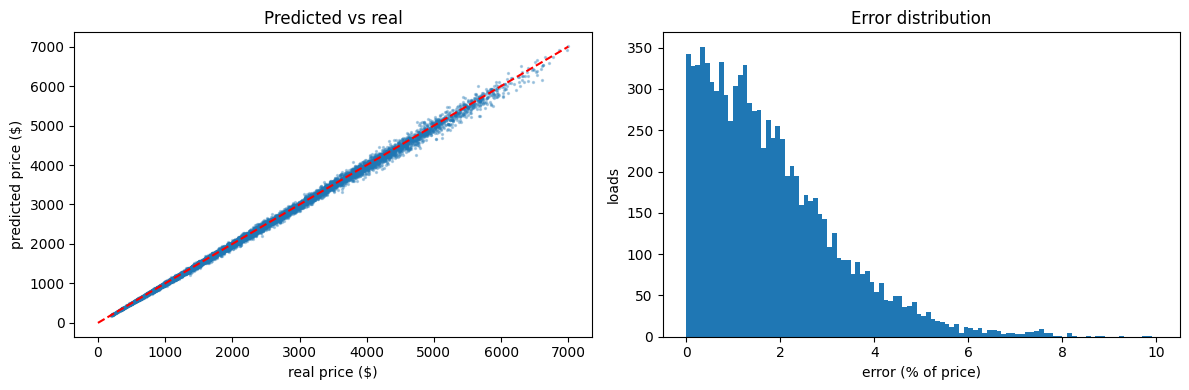

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(res.posted_rate, res.pred, s=2, alpha=0.3)
lim = [0, res.posted_rate.max()]
ax1.plot(lim, lim, color='red', ls='--')                # perfect prediction line
ax1.set_xlabel('real price ($)'); ax1.set_ylabel('predicted price ($)'); ax1.set_title('Predicted vs real')
ax2.hist(res.ape, bins=100, range=(0, 10))
ax2.set_xlabel('error (% of price)'); ax2.set_ylabel('loads'); ax2.set_title('Error distribution')
plt.tight_layout(); plt.show()

In [54]:
res['distance_band'] = pd.cut(res.distance, [0, 300, 600, 1000, 1500, 2000, 3500])
for col in ['equipment', 'distance_band']:
    print(res.groupby(col, observed=True).agg(loads=('err', 'size'),
          MAE=('err', lambda e: e.abs().mean()), MAPE=('ape', 'mean')).round(2), '\n')

           loads    MAE  MAPE
equipment                    
Dry Van     5275  36.00  1.65
Flatbed     1746  54.89  2.25
Reefer      2358  45.77  1.81 

               loads    MAE  MAPE
distance_band                    
(0, 300]         770  11.20  2.03
(300, 600]      1909  20.53  1.89
(600, 1000]     2303  32.06  1.80
(1000, 1500]    1735  44.90  1.75
(1500, 2000]    1149  61.58  1.72
(2000, 3500]    1513  81.56  1.72 



**Cities never seen in training.** 8 validation cities (12.1% of validation loads) don't exist in the training data. To check that the model still works for them, 8 training cities are hidden from the training part, then the error is compared on loads with seen vs unseen cities.

In [55]:
rng = np.random.default_rng(0)
hidden = [str(c) for c in rng.choice(sorted(data_clean.pickup.unique()), 8, replace=False)]
touch = data_clean.pickup.isin(hidden) | data_clean.delivery.isin(hidden)

m2 = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
        categorical_features=[base.index('equip')], random_state=0)
m2.fit(data_clean.loc[tr & ~touch, base], data_clean.loc[tr & ~touch, 'rpm'])

print("hidden cities:", hidden)
for name, mask in [('seen cities', te & ~touch), ('UNSEEN cities', te & touch)]:
    pred = m2.predict(data_clean.loc[mask, base]) * data_clean.loc[mask, 'distance']
    print(f"{name:14s} {mask.sum():5d} loads |", evaluate(data_clean.loc[mask, 'posted_rate'], pred))

hidden cities: ['Providence', 'Austin', 'Albuquerque', 'Kansas City', 'Detroit', 'Dallas', 'Amarillo', 'Lubbock']
seen cities     7661 loads | MAE $   42.0 | MAPE  1.81%
UNSEEN cities   1718 loads | MAE $   45.6 | MAPE  1.90%


**Observations**
- Fold B (Sep–Oct): **MAE \$42, median error \$28, R² 0.998, 96.8% of loads within 5%** of the real price.
- **Predicted vs real:** points follow the perfect-prediction line from \$200 to \$7,000. **Error distribution:** median error 1.5%, and almost no load above 8%.
- The error in \$ grows with distance, but **in % it stays flat (about 1.7–2%)**, as expected when modelling price per mile.
- Flatbed is the hardest (2.25%), probably because it has the fewest loads (18%).
- Small **negative bias (−\$15)**: Sep–Oct prices were above the Jan–Aug average. A trend or recency feature could reduce it (next steps).
- **New cities:** with 8 cities hidden from training, the error rises only from about 1.81% to 1.90%. The coordinates generalise, which matters because 12% of the validation loads involve a city never seen in training.

## 7. Final model and predictions
**For information: error on raw data.** The model is trained on clean data only, but Spotter scores the predictions against the real Nov–Dec prices, which may contain about 1.4% corrupted rates like the training data. To estimate that case, the same model is evaluated on raw Sep–Oct, corrupted rows included.

In [56]:
final_feats = base
tr, te = folds['B (test Sep–Oct)']
model = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
            categorical_features=[final_feats.index('equip')], random_state=0)
model.fit(data_clean.loc[tr, final_feats], data_clean.loc[tr, 'rpm'])

full_test = data[data.date >= '2025-09-01'].copy()      # includes the corrupted rows
full_test['weight'] = full_test.weight.abs().fillna(WEIGHT_MEDIAN)
full_test['equip'] = full_test.equipment.map({'Dry Van': 0, 'Flatbed': 1, 'Reefer': 2})
full_test['dow'] = full_test.date.dt.dayofweek
pred = model.predict(full_test[final_feats]) * full_test.distance
print("Sep–Oct incl. corrupted rows:", evaluate(full_test.posted_rate, pred))

Sep–Oct incl. corrupted rows: MAE $   98.0 | MAPE  4.32%


Including the corrupted rows raises Sep–Oct MAE from **\$42 to \$98**. Almost all of the gap comes from the ~1.4% of rows whose price is about 3.5× off, which no model can predict.

Next: train the final model on **all** clean Jan–Oct data, predict the 12,000 validation loads, then the 31 December chart inputs.

In [57]:
final_model = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
                  categorical_features=[final_feats.index('equip')], random_state=0)
final_model.fit(data_clean[final_feats], data_clean['rpm'])

v = val.copy()
v['weight'] = v.weight.abs().fillna(WEIGHT_MEDIAN)
v['equip'] = v.equipment.map({'Dry Van': 0, 'Flatbed': 1, 'Reefer': 2})
v['dow'] = v.date.dt.dayofweek
v['predicted_rate'] = final_model.predict(v[final_feats]) * v.distance

template = pd.read_csv('data/validation_predictions_template.csv')
out = template[['load_id']].merge(v[['load_id', 'predicted_rate']], on='load_id', how='left')
print(out.predicted_rate.isna().sum(), "missing |", len(out), "rows")
out.to_csv('validation_predictions.csv', index=False)

0 missing | 12000 rows


In [58]:
dec = pd.read_csv('data/december_chart_inputs.csv', parse_dates=['date'])
coords = data.groupby('pickup')[['pickup_lat', 'pickup_lon']].first()
dcoords = data.groupby('delivery')[['delivery_lat', 'delivery_lon']].first()
dec = dec.join(coords, on='pickup').join(dcoords, on='delivery')
dec['equip'] = dec.equipment.map({'Dry Van': 0, 'Flatbed': 1, 'Reefer': 2})
dec['dow'] = dec.date.dt.dayofweek
dec['predicted_rate'] = (final_model.predict(dec[final_feats]) * dec.distance).round(2)

orig = pd.read_csv('data/december_chart_inputs.csv')
orig['predicted_rate'] = dec['predicted_rate'].values
orig.to_csv('data/december_chart_inputs.csv', index=False)
print(orig.head())

      pickup    delivery  distance equipment  weight        date  \
0  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   

   predicted_rate  
0          819.32  
1          826.83  
2          831.39  
3          836.07  
4          830.78  


The December chart inputs have no coordinates, so they are taken from the same cities in the training data. Since only the date changes, the predicted curve shows the weekly pattern the model learned: highest on Thursday (≈ \$836), lowest on Sunday (≈ \$814). Holidays are not modelled, because the training data contains no December.

Files produced: `validation_predictions.csv`, `data/december_chart_inputs.csv` (filled), and `scorer_results/candidate_december.png` from `score.py`.

## 8. Summary

| Check | Result | Action |
|---|---|---|
| Missing `weight` | 300 rows | Fill with median |
| Negative `weight` | 292 rows, same distribution as positive (KS p ≈ 0.70) | Sign errors → `abs()` |
| Missing `market_index` | 374 rows | Fill with same-day average |
| `posted_rate` missing / ≤ 0 | None | – |
| `distance` reliability | Consistent per route (±12% for 99.8%) | Trusted |
| Coordinates | One position per city, a few approximate | Used as location hints |
| New cities | 8 cities (12.1% of validation loads) never seen in training | Use coordinates + distance, not city names |
| Corrupted rates | 677 rows (1.41%), 3.5–6× off | Excluded from training |
| `quote_signal` | Flips by month; noise in Aug and in Nov–Dec | Excluded from the final model |
| `market_index` | Drifts after July, worse on both folds | Excluded from the final model |
| **Final model** | Gradient boosting on price per mile | **Aug: \$40.9 (1.74%) · Sep–Oct: \$42.0 (1.80%)** |

## Checklist
- [x] Confirm the weight sign-error hypothesis (compare negative vs positive weight distributions)
- [x] Understand and fix each feature in its own section (corrupted rates, `weight`, `market_index`)
- [x] Explore `quote_signal` month by month + label-free regime test
- [x] Time-based folds: train Jan–Jul → test Aug; train Jan–Aug → test Sep–Oct
- [x] Baseline model, then gradient boosting on price per mile (without `quote_signal`)
- [x] Predict validation + December chart inputs, run `score.py`